<a href="https://colab.research.google.com/github/carlosvint/scrapping--MCIB-B/blob/master/Analisis_de_Datos_Dataset_Ciberseguridad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats


In [2]:
SEED = 42
np.random.seed(SEED)

In [3]:
df = pd.read_csv('/content/synthetic_network_logs.csv')

In [4]:
df

,duration,protocol,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,count,srv_count,dst_host_same_srv_rate,label
0,0.017501,tcp,47236.0,86.0,0,1,0,0,0,0,0,475,512,0.956367,dos
1,7.826195,tcp,631.0,529.0,0,0,0,0,0,0,0,23,9,0.635447,normal
2,3.182725,tcp,129.0,119.0,0,0,0,0,0,1,0,67,40,0.200217,probe
3,0.228845,tcp,33824.0,83.0,0,0,0,0,0,0,0,512,443,1.000000,dos
4,6.303190,udp,82.0,548.0,0,0,0,2,0,0,0,20,11,0.615022,normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,5.591345,tcp,258.0,570.0,0,0,0,0,0,1,0,23,7,0.553958,normal
9996,6.793826,tcp,704.0,573.0,0,0,0,1,0,1,0,21,16,0.603685,normal
9997,3.242299,tcp,192.0,75.0,0,0,0,0,0,1,0,16,17,0.658331,normal
9998,6.676045,udp,407.0,113.0,0,0,0,0,0,1,0,17,15,0.648488,normal


In [5]:
df.columns

Index(['duration', 'protocol', 'src_bytes', 'dst_bytes', 'land',
       'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in',
       'num_compromised', 'count', 'srv_count', 'dst_host_same_srv_rate',
       'label'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   duration                9790 non-null   float64
 1   protocol                10000 non-null  object 
 2   src_bytes               9902 non-null   float64
 3   dst_bytes               9914 non-null   float64
 4   land                    10000 non-null  int64  
 5   wrong_fragment          10000 non-null  int64  
 6   urgent                  10000 non-null  int64  
 7   hot                     10000 non-null  int64  
 8   num_failed_logins       10000 non-null  int64  
 9   logged_in               10000 non-null  int64  
 10  num_compromised         10000 non-null  int64  
 11  count                   10000 non-null  int64  
 12  srv_count               10000 non-null  int64  
 13  dst_host_same_srv_rate  10000 non-null  float64
 14  label                   10000 non-null 

In [7]:
df['label'].unique()

array(['dos', 'normal', 'probe', 'r2l', 'u2r'], dtype=object)

In [8]:
df['protocol'].unique()

array(['tcp', 'udp', 'icmp'], dtype=object)

In [9]:
df.shape

(10000, 15)

In [10]:
display(df.head())

,duration,protocol,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,count,srv_count,dst_host_same_srv_rate,label
0,0.017501,tcp,47236.0,86.0,0,1,0,0,0,0,0,475,512,0.956367,dos
1,7.826195,tcp,631.0,529.0,0,0,0,0,0,0,0,23,9,0.635447,normal
2,3.182725,tcp,129.0,119.0,0,0,0,0,0,1,0,67,40,0.200217,probe
3,0.228845,tcp,33824.0,83.0,0,0,0,0,0,0,0,512,443,1.000000,dos
4,6.303190,udp,82.0,548.0,0,0,0,2,0,0,0,20,11,0.615022,normal


In [11]:
df.tail()

,duration,protocol,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,count,srv_count,dst_host_same_srv_rate,label
9995,5.591345,tcp,258.0,570.0,0,0,0,0,0,1,0,23,7,0.553958,normal
9996,6.793826,tcp,704.0,573.0,0,0,0,1,0,1,0,21,16,0.603685,normal
9997,3.242299,tcp,192.0,75.0,0,0,0,0,0,1,0,16,17,0.658331,normal
9998,6.676045,udp,407.0,113.0,0,0,0,0,0,1,0,17,15,0.648488,normal
9999,8.420998,tcp,340.0,80.0,0,0,0,1,0,1,0,24,24,0.348616,normal


In [18]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'count':missing, 'percent': missing_pct})
missing_df = missing_df[missing_df['count'] > 0]

In [19]:
missing_df

,count,percent
duration,210,2.10
src_bytes,98,0.98
dst_bytes,86,0.86


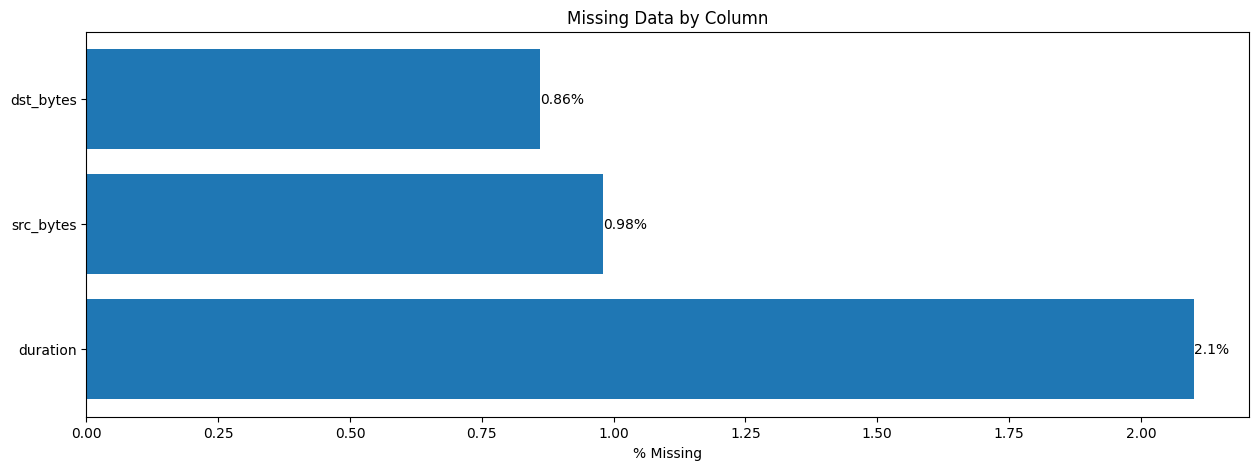

In [23]:
fig, ax = plt.subplots(figsize=(15,5))
ax.barh(missing_df.index, missing_df['percent'])
ax.set_xlabel('% Missing')
ax.set_title('Missing Data by Column')
for i, (col, row) in enumerate(missing_df.iterrows()):
  ax.text(row['percent'], i, f"{row['percent']}%", va = 'center')
plt.show()

In [25]:
for col in ['duration', 'dst_bytes', 'src_bytes']:
  is_missing = df[col].isnull()
  miss_rate_by_label = df.groupby('label')[col].apply(lambda x: x.isnull().mean())
  print(col)
  print(miss_rate_by_label)


duration
label
dos       0.018975
normal    0.020337
probe     0.034908
r2l       0.012853
u2r       0.008929
Name: duration, dtype: float64
dst_bytes
label
dos       0.010497
normal    0.007606
probe     0.006160
r2l       0.012853
u2r       0.026786
Name: dst_bytes, dtype: float64
src_bytes
label
dos       0.009285
normal    0.010913
probe     0.005133
r2l       0.005141
u2r       0.017857
Name: src_bytes, dtype: float64


In [26]:
df.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,count,srv_count,dst_host_same_srv_rate
count,9790.000000,9902.000000,9914.000000,10000.000000,10000.000000,10000.000000,10000.0000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,3.803251,12954.503535,282.270224,0.001400,0.137300,0.002000,0.6901,0.085300,0.456900,0.062100,130.690300,124.118900,0.613298
std,3.244494,25738.865061,207.769283,0.037392,0.425754,0.044679,1.3539,0.437313,0.498164,0.368317,187.732195,187.953148,0.229838
min,0.000622,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000
25%,0.520733,316.000000,104.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,17.000000,15.000000,0.444095
50%,3.446534,613.500000,229.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,23.000000,21.000000,0.587533
75%,5.971788,2445.750000,437.000000,0.000000,0.000000,0.000000,1.0000,0.000000,1.000000,0.000000,118.000000,62.000000,0.784866
max,25.584531,179807.000000,1217.000000,1.000000,4.000000,1.000000,15.0000,6.000000,1.000000,8.000000,512.000000,512.000000,1.000000


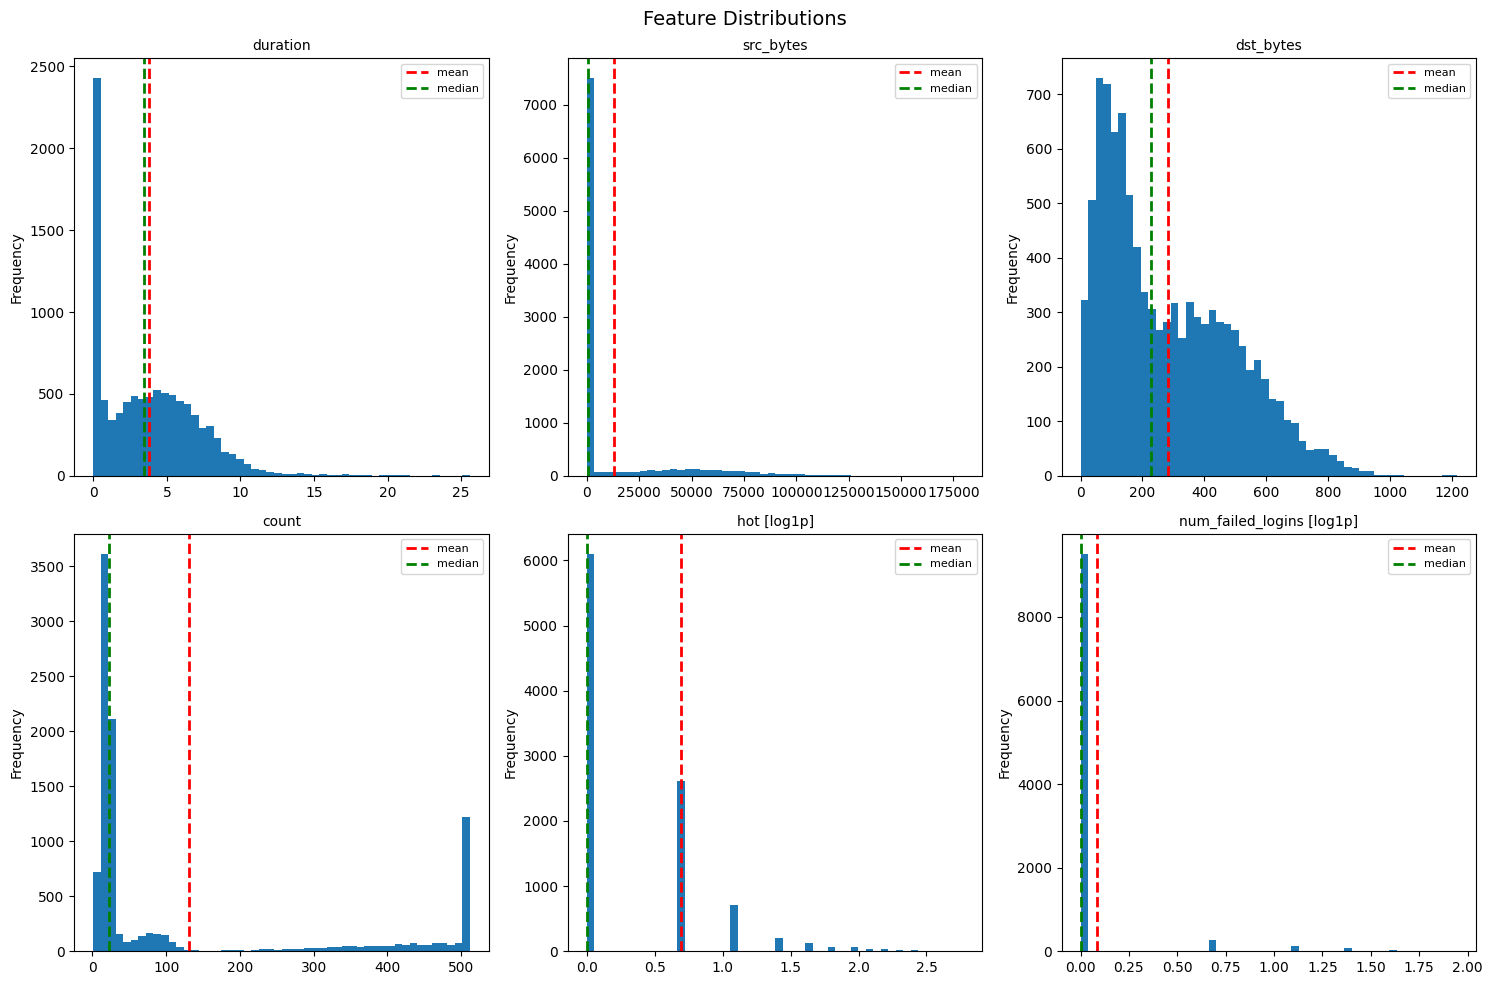

In [42]:
features = ['duration', 'src_bytes', 'dst_bytes', 'count', 'hot', 'num_failed_logins']

fig, axes = plt.subplots(2, 3, figsize = (15,10))
axes = axes.flatten()

for i, feat in enumerate(features):
  data = df[feat].dropna()
  ax = axes[i]

  use_log = data.skew() > 3
  plot_data = np.log1p(data) if use_log else data

  ax.hist(plot_data, bins=50)
  ax.axvline(data.mean(), color='red', linestyle='dashed', linewidth=2, label=f'mean')
  ax.axvline(data.median(), color='green', linestyle='dashed', linewidth=2, label = f'median')
  ax.set_title(f'{feat}' + (' [log1p]' if use_log else ''), fontsize=10)
  ax.legend(fontsize=8)
  ax.set_ylabel('Frequency')

plt.suptitle('Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()

In [43]:
skew = df[features].skew().sort_values(ascending=False)

In [44]:
skew

,0
num_failed_logins,6.398249
hot,4.038940
src_bytes,2.093915
count,1.285594
duration,0.964893
dst_bytes,0.702170


In [47]:
proto_counts = df['protocol'].value_counts()

In [48]:
proto_counts

,count
protocol,
tcp,6346
udp,2150
icmp,1504


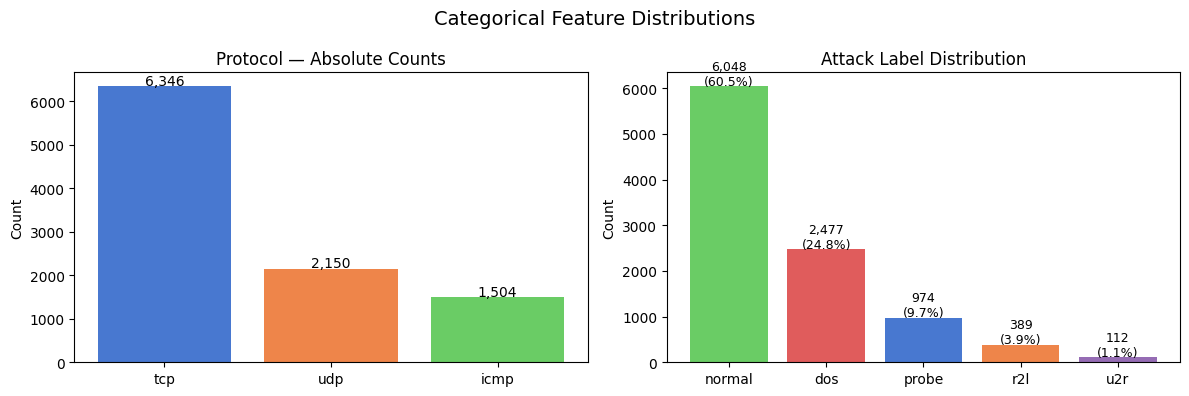

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(proto_counts.index, proto_counts.values, color=['#4878d0', '#ee854a', '#6acc65'])
axes[0].set_title('Protocol — Absolute Counts')
axes[0].set_ylabel('Count')
for i, v in enumerate(proto_counts.values):
    axes[0].text(i, v + 30, f'{v:,}', ha='center', fontsize=10)

label_counts = df['label'].value_counts()
colors = ['#6acc65', '#e05c5c', '#4878d0', '#ee854a', '#956cb4']
axes[1].bar(label_counts.index, label_counts.values, color=colors)
axes[1].set_title('Attack Label Distribution')
axes[1].set_ylabel('Count')
for i, v in enumerate(label_counts.values):
    axes[1].text(i, v + 30, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=9)

plt.suptitle('Categorical Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()

/tmp/ipykernel_5458/136306858.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_5458/136306858.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_5458/136306858.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_5458/136306858.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


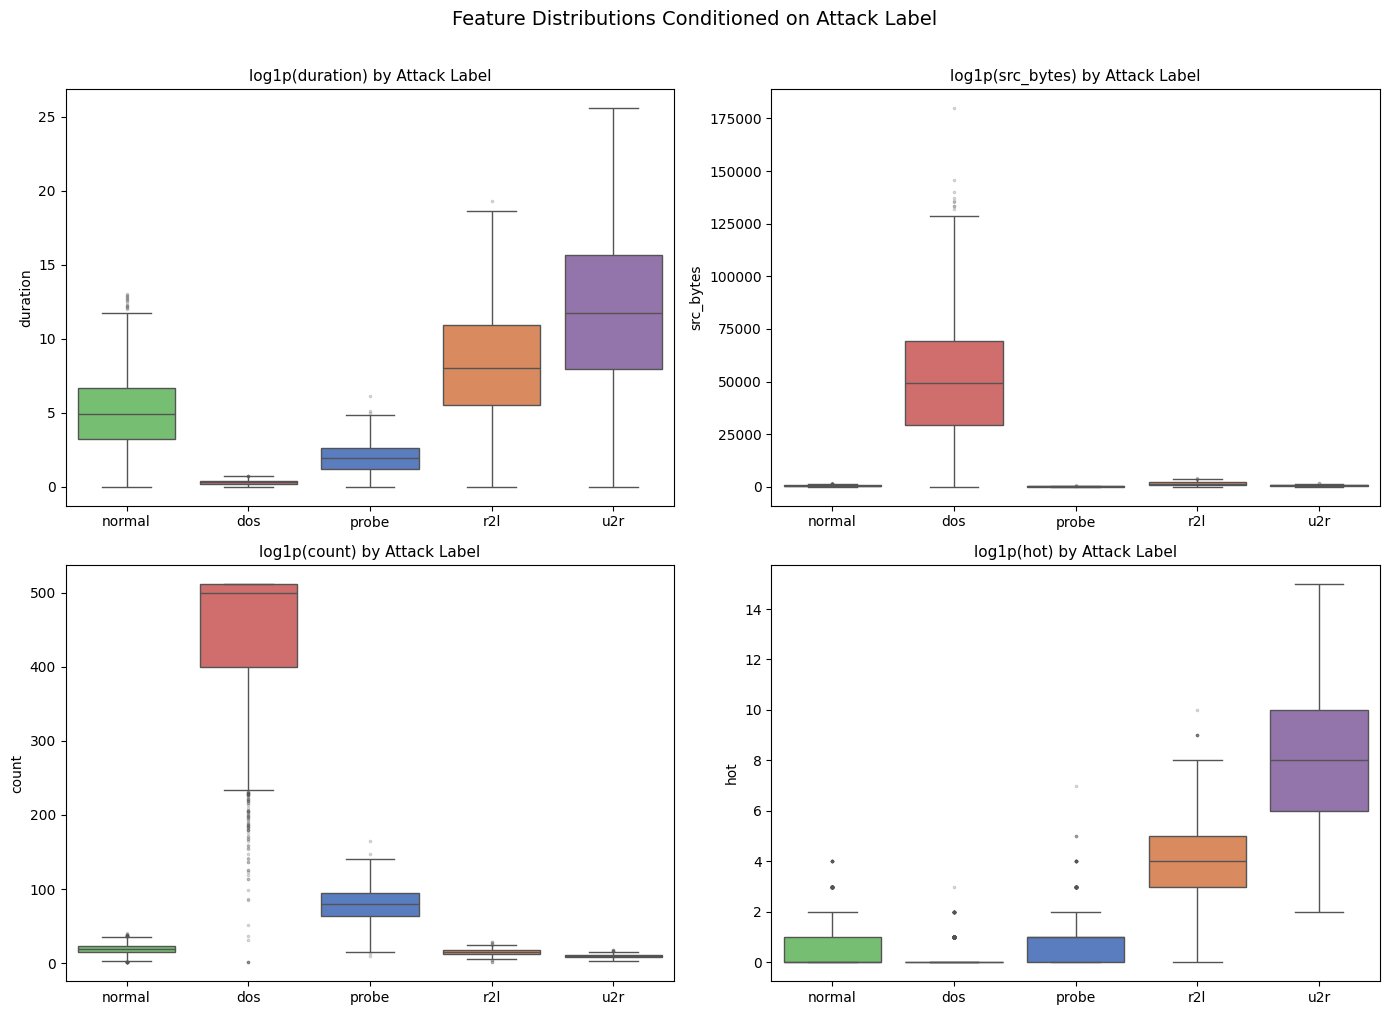

In [54]:
label_order = ['normal', 'dos', 'probe', 'r2l', 'u2r']
palette = {'normal': '#6acc65', 'dos': '#e05c5c',
           'probe': '#4878d0', 'r2l': '#ee854a', 'u2r': '#956cb4'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

features_box = ['duration', 'src_bytes', 'count', 'hot']

for i, feat in enumerate(features_box):
    ax = axes[i]
    # Log transform for visibility
    df_plot = df.copy()
    # df_plot[feat] = np.log1p(df_plot[feat].fillna(0))
    df_plot[feat] = df_plot[feat].fillna(0)
    sns.boxplot(
        data=df_plot, x='label', y=feat,
        order=label_order,
        palette=palette,
        ax=ax,
        flierprops=dict(marker='.', alpha=0.3, ms=3)
    )
    ax.set_title(f'log1p({feat}) by Attack Label', fontsize=11)
    ax.set_xlabel('')

plt.suptitle('Feature Distributions Conditioned on Attack Label', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

/tmp/ipykernel_5458/3815336220.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Label', markerscale=3, fontsize=9)


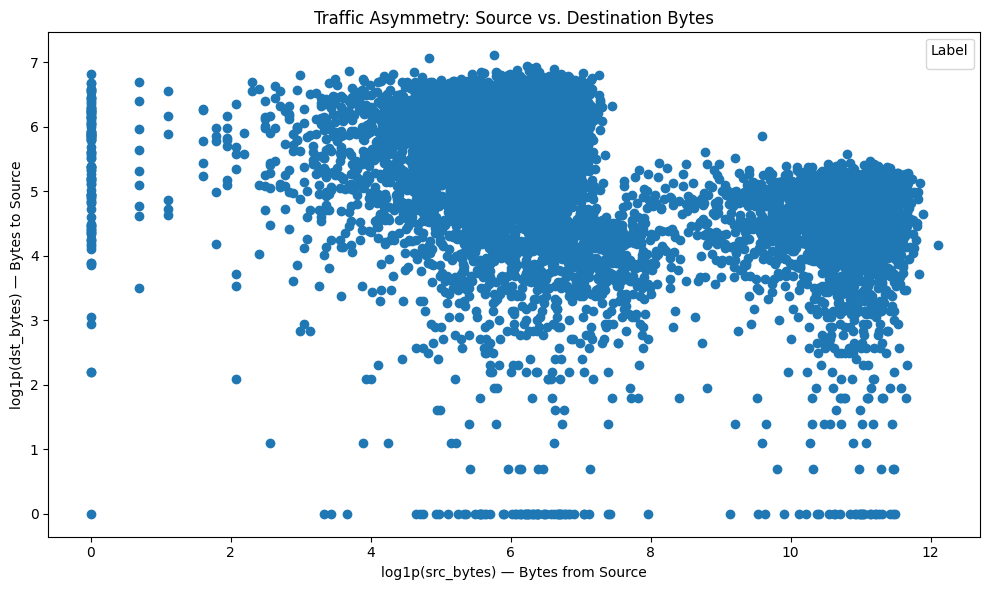

In [56]:
fig, ax = plt.subplots(figsize=(10, 6))


ax.scatter(
      np.log1p(df['src_bytes'].fillna(0)),
      np.log1p(df['dst_bytes'].fillna(0)),
      # label=label, alpha=0.25, s=12,
      # color=palette[label]
  )

ax.set_xlabel('log1p(src_bytes) — Bytes from Source')
ax.set_ylabel('log1p(dst_bytes) — Bytes to Source')
ax.set_title('Traffic Asymmetry: Source vs. Destination Bytes')
ax.legend(title='Label', markerscale=3, fontsize=9)
plt.tight_layout()
plt.show()

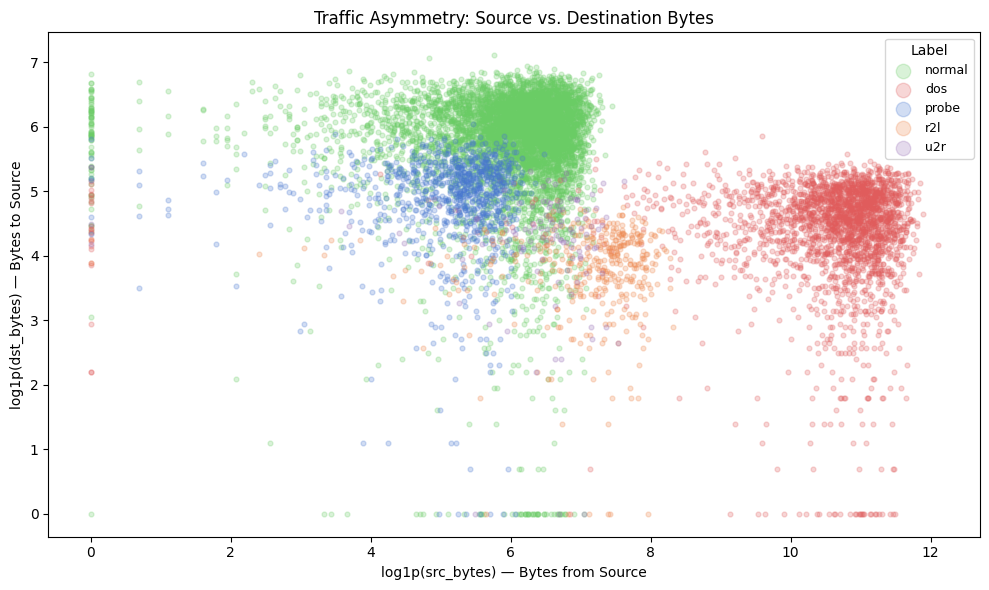

In [66]:
fig, ax = plt.subplots(figsize=(10, 6))

for label in label_order:
    subset = df[df['label'] == label]
    ax.scatter(
        np.log1p(subset['src_bytes'].fillna(0)),
        np.log1p(subset['dst_bytes'].fillna(0)),
        label=label,
        alpha=0.25, s=12,
        color=palette[label]
    )

ax.set_xlabel('log1p(src_bytes) — Bytes from Source')
ax.set_ylabel('log1p(dst_bytes) — Bytes to Source')
ax.set_title('Traffic Asymmetry: Source vs. Destination Bytes')
ax.legend(title='Label', markerscale=3, fontsize=9)
plt.tight_layout()
plt.show()

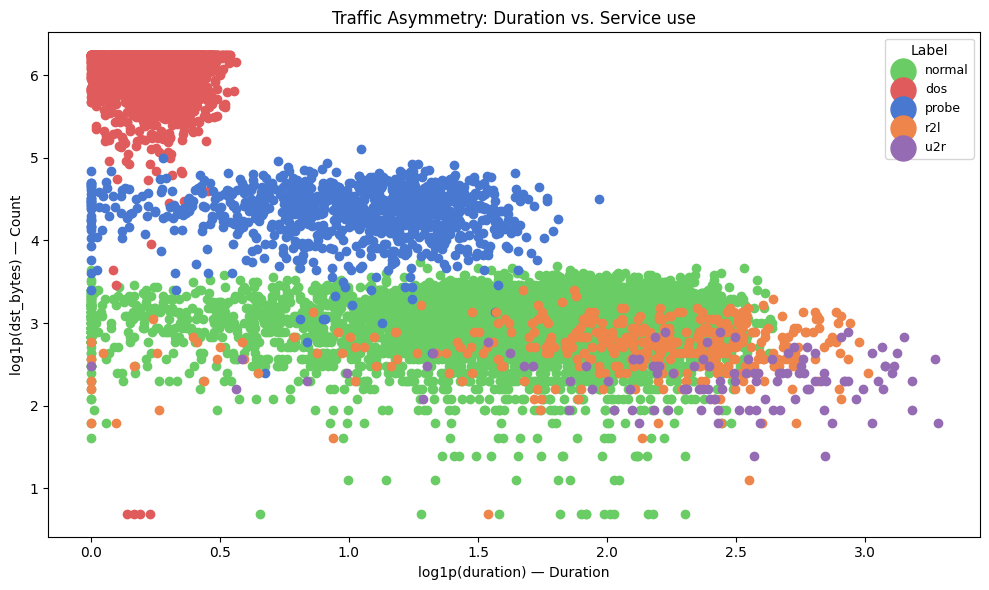

In [65]:
fig, ax = plt.subplots(figsize=(10, 6))

for label in label_order:
    subset = df[df['label'] == label]
    ax.scatter(
        np.log1p(subset['duration'].fillna(0)),
        np.log1p(subset['count'].fillna(0)),
        label=label,
        # alpha=0.25, s=12,
        color=palette[label]
    )

ax.set_xlabel('log1p(duration) — Duration')
ax.set_ylabel('log1p(dst_bytes) — Count')
ax.set_title('Traffic Asymmetry: Duration vs. Service use')
ax.legend(title='Label', markerscale=3, fontsize=9)
plt.tight_layout()
plt.show()

In [67]:
crosstab = pd.crosstab(df['protocol'], df['label'], normalize='index')
crosstab = crosstab[label_order]  # consistent column order

In [68]:
crosstab

label,normal,dos,probe,r2l,u2r
protocol,,,,,
icmp,0.194814,0.661569,0.124335,0.016622,0.002660
tcp,0.656319,0.216199,0.059565,0.051371,0.016546
udp,0.739535,0.051163,0.190233,0.017674,0.001395


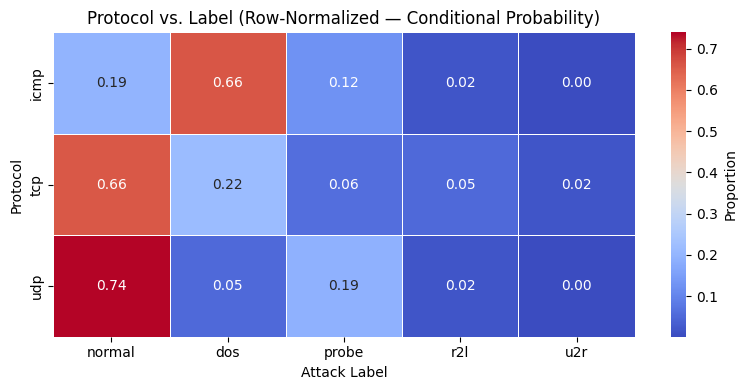

In [70]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(
    crosstab, annot=True, fmt='.2f', cmap='coolwarm',
    linewidths=0.5, ax=ax, cbar_kws={'label': 'Proportion'}
)
ax.set_title('Protocol vs. Label (Row-Normalized — Conditional Probability)', fontsize=12)
ax.set_xlabel('Attack Label')
ax.set_ylabel('Protocol')
plt.tight_layout()
plt.show()

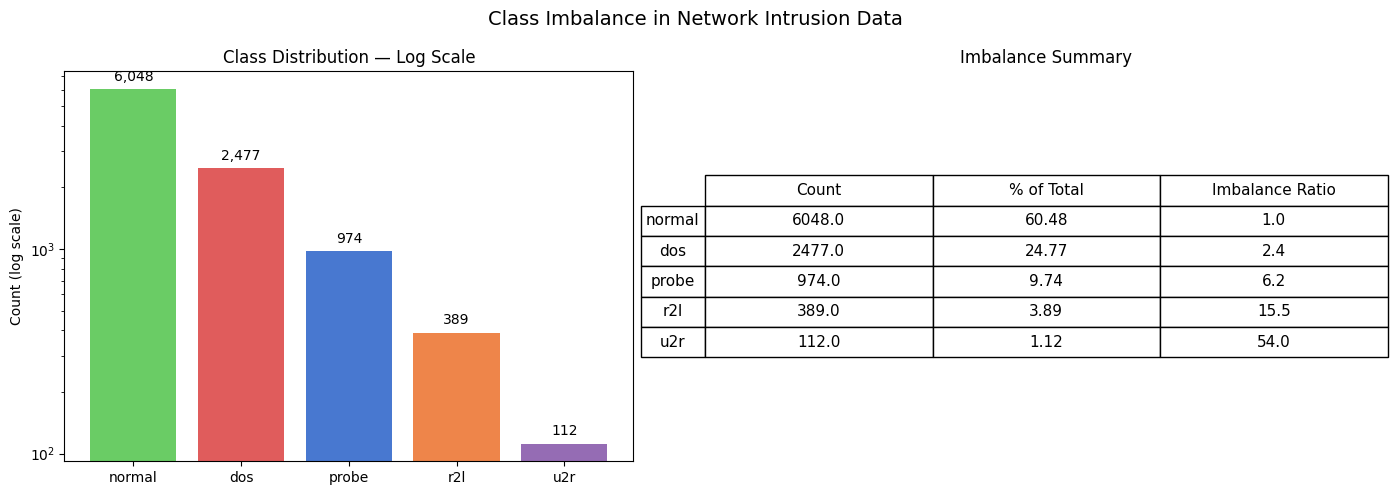

In [72]:
label_counts = df['label'].value_counts()[label_order]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Log-scale bar
bars = axes[0].bar(label_counts.index, label_counts.values,
                   color=[palette[l] for l in label_counts.index])
axes[0].set_yscale('log')
axes[0].set_ylabel('Count (log scale)')
axes[0].set_title('Class Distribution — Log Scale')
for bar, val in zip(bars, label_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val * 1.1,
                f'{val:,}', ha='center', fontsize=10)


max_count = label_counts.max()
ratio_df = pd.DataFrame({
    'count': label_counts,
    'pct': (label_counts / len(df) * 100).round(2),
    'imbalance_ratio': (max_count / label_counts).round(1)
})

axes[1].axis('off')
table = axes[1].table(
    cellText=ratio_df.values,
    rowLabels=ratio_df.index,
    colLabels=['Count', '% of Total', 'Imbalance Ratio'],
    cellLoc='center', rowLoc='center', loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)
axes[1].set_title('Imbalance Summary', fontsize=12)

plt.suptitle('Class Imbalance in Network Intrusion Data', fontsize=14)
plt.tight_layout()
plt.show()

In [73]:
corr = df.select_dtypes(include=['float64', 'int64']).corr(method='spearman')

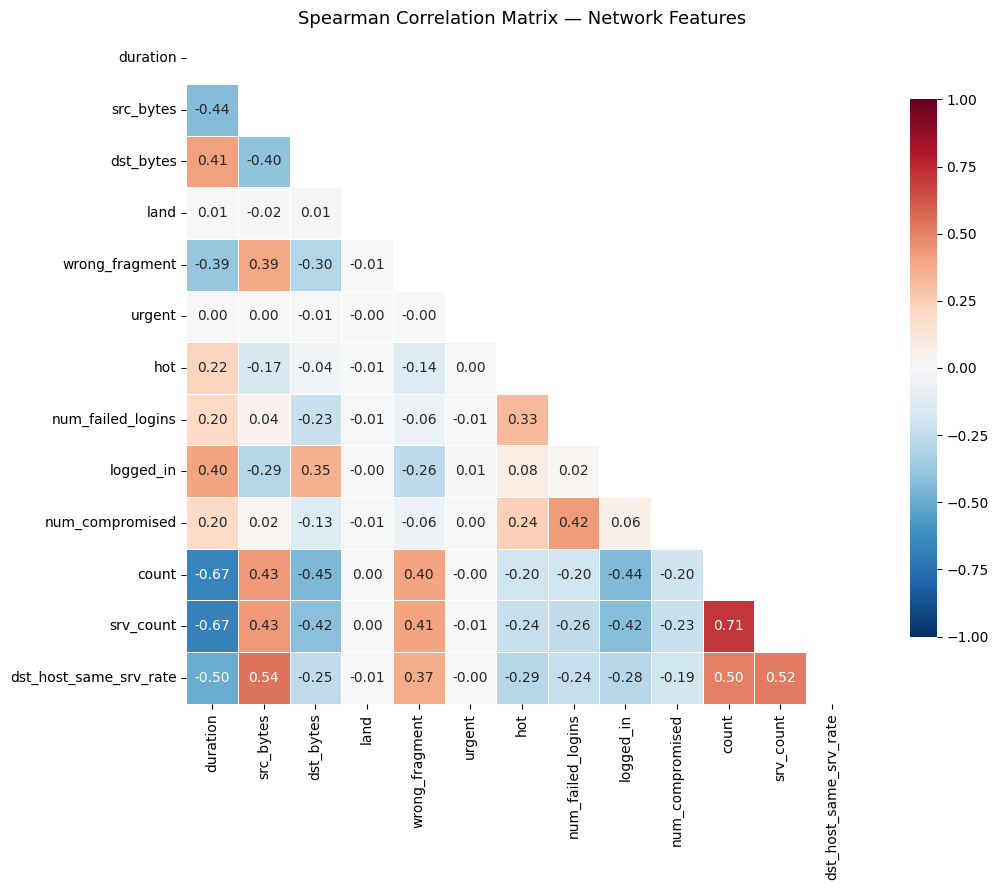

In [75]:
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    corr,
    mask=mask,
    cmap='RdBu_r', center=0,
    annot=True, fmt='.2f', linewidths=0.5,
    vmin=-1, vmax=1, square=True, ax=ax,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Spearman Correlation Matrix — Network Features', fontsize=13)
plt.tight_layout()
plt.show()

In [76]:
def iqr_outlier_mask(series):
    """Return boolean mask: True where value is an IQR outlier."""
    s = series.dropna()
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    return (series < lower) | (series > upper)

In [78]:
outlier_features = ['src_bytes', 'count', 'duration', 'hot']
df_out = df.copy()

In [83]:
for feat in outlier_features:
    mask = iqr_outlier_mask(df_out[feat])
    n_out = mask.sum()
    # print(n_out)
    pct_out = n_out / len(df_out) * 100
    pct_attack = (df_out.loc[mask, 'label'] != 'normal').mean() * 100
    print(f'{feat:<20} {n_out:>12,} {pct_out:>11.1f}% {pct_attack:>19.1f}%')

src_bytes                   2,359        23.6%               100.0%
count                       2,329        23.3%               100.0%
duration                       73         0.7%               100.0%
hot                           568         5.7%                85.2%


/tmp/ipykernel_5458/1446771290.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_5458/1446771290.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


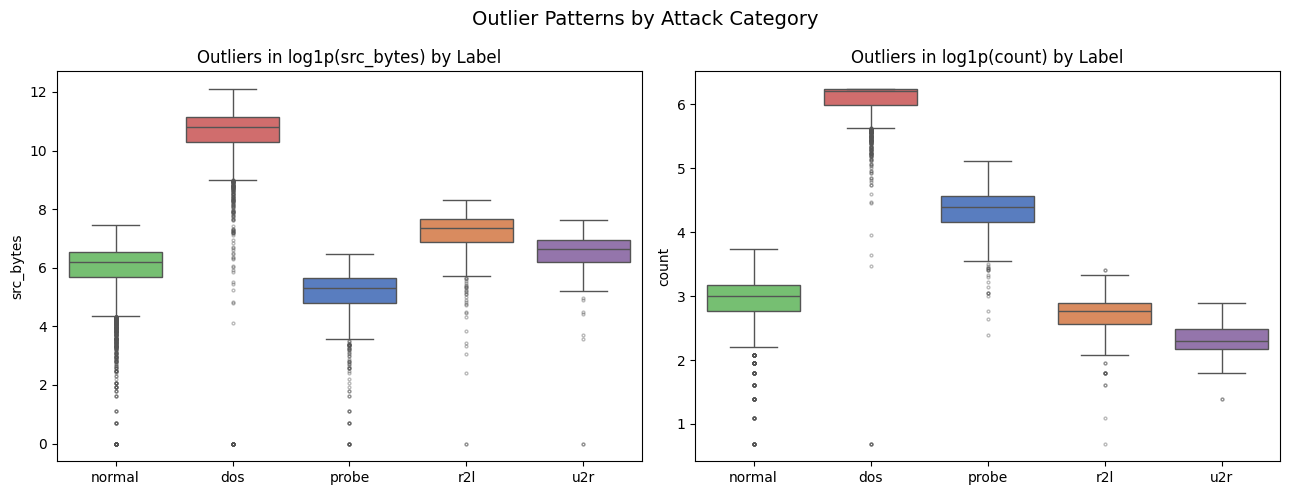

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, feat in zip(axes, ['src_bytes', 'count']):
    df_plot = df.copy()
    df_plot[feat] = np.log1p(df_plot[feat].fillna(0))
    sns.boxplot(
        data=df_plot, x='label', y=feat,
        order=label_order, palette=palette, ax=ax,
        flierprops=dict(marker='.', alpha=0.4, ms=4, color='gray')
    )
    ax.set_title(f'Outliers in log1p({feat}) by Label')
    ax.set_xlabel('')

plt.suptitle('Outlier Patterns by Attack Category', fontsize=14)
plt.tight_layout()
plt.show()